In [2]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data_std = pd.read_csv("/home/abdoulaye/Documents/Orange Digital center/projets/projet_data/data/ai_student_impact_dataset.csv")
data_std.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


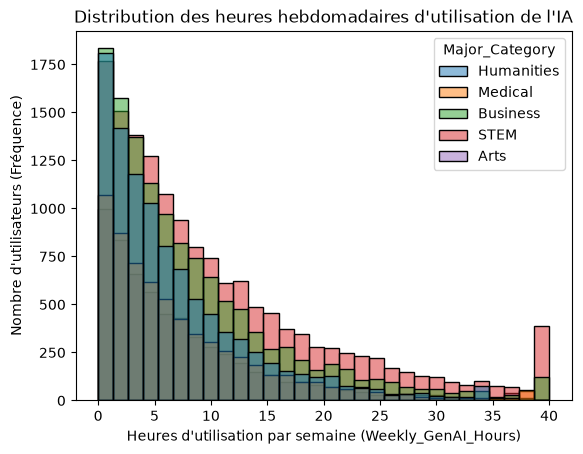

In [54]:
sns.histplot(data=data_std, x="Weekly_GenAI_Hours", bins=30, hue="Major_Category")
plt.title("Distribution des heures hebdomadaires d'utilisation de l'IA")
plt.xlabel("Heures d'utilisation par semaine (Weekly_GenAI_Hours)")
plt.ylabel("Nombre d'utilisateurs (Fréquence)")
plt.show()

La distribution de Weekly_GenAI_Hours est asymétrique à droite. 
La moyenne (8.43h) est tirée vers le haut par des valeurs aberrantes — 
des étudiants utilisant jusqu'à 40h/semaine — ce qui la rend peu représentative. 
La médiane (5.8h) est plus fiable. 
Par filière, les étudiants STEM dominent les usages extrêmes de l'IA.

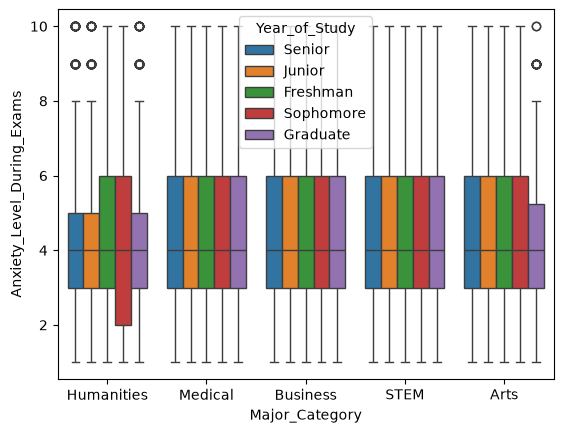

In [56]:
sns.boxplot(data=data_std, y="Anxiety_Level_During_Exams", x="Major_Category", hue="Year_of_Study")

plt.show()

Le boxplot permet de visualiser en un seul graphique la médiane, les quartiles Q1 et Q3, l'IQR et les valeurs aberrantes. 
Sans segmentation, les 5 boxplots de Anxiety_Level_During_Exams par Major_Category affichent des niveaux quasi identiques — aucun outlier visible. 
Mais en ajoutant hue="Year_of_Study", des valeurs aberrantes apparaissent dans certaines années d'étude, 
notamment chez les Seniors en Humanities. Cela démontre l'importance de segmenter les données pour révéler des patterns cachés invisibles à l'échelle globale.

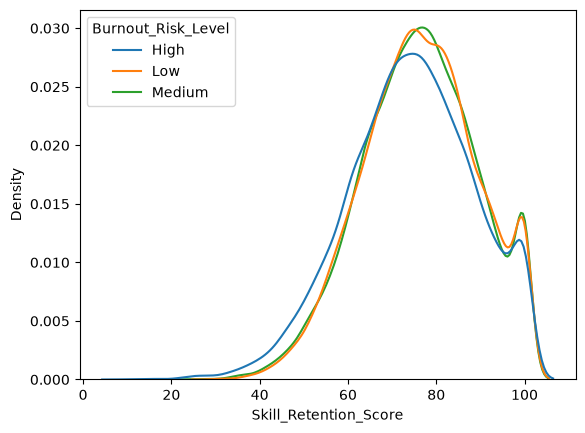

In [64]:
sns.kdeplot(data=data_std, x="Skill_Retention_Score", hue="Burnout_Risk_Level", common_norm=False)
plt.show()

Le KDE plot (Kernel Density Estimation) est une courbe de densité qui montre la distribution d'une variable de façon lissée — contrairement à l'histogramme il n'y a pas de barres mais une courbe continue. Sur Skill_Retention_Score, la distribution est asymétrique à gauche due aux 216 outliers vers le bas (borne basse à 39.26). La majorité des étudiants se concentre entre 60 et 100 indiquant une bonne rétention globale. En ajoutant hue="Burnout_Risk_Level" et common_norm=False pour normaliser, on observe que Low et Medium burnout ont des courbes quasi identiques tandis que High burnout est légèrement décalé vers les scores bas — confirmant que le burnout élevé impacte légèrement mais pas dramatiquement la rétention des compétences.

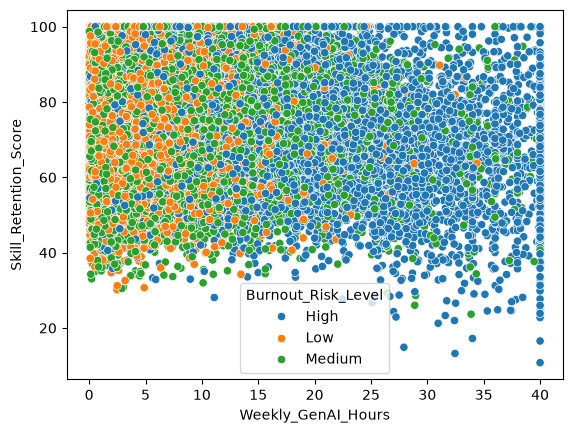

In [36]:
sns.scatterplot(data=data_std, x="Weekly_GenAI_Hours", y="Skill_Retention_Score", hue="Burnout_Risk_Level")
plt.show()

Le scatter plot met en relation deux variables numériques pour détecter une tendance ou corrélation. 
Avec 50 000 points, le graphique est illisible — 
les points se superposent complètement rendant toute interprétation impossible.

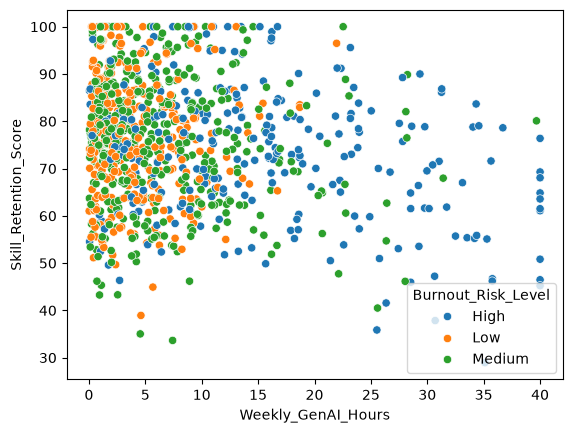

In [37]:
data_sample = data_std.sample(1000)
sns.scatterplot(
    data=data_sample,
    x="Weekly_GenAI_Hours",
    y="Skill_Retention_Score",
    hue="Burnout_Risk_Level"
)
plt.show()

En réduisant à 1 000 points aléatoires avec sample(), le graphique devient lisible. 
On observe une légère tendance — les étudiants avec peu d'heures IA tendent vers un burnout Low et une meilleure rétention. 
Cependant 1 000 points sur 50 000 reste un échantillon limité — les conclusions visuelles doivent être vérifiées avec des outils statistiques
 plus rigoureux comme la heatmap.

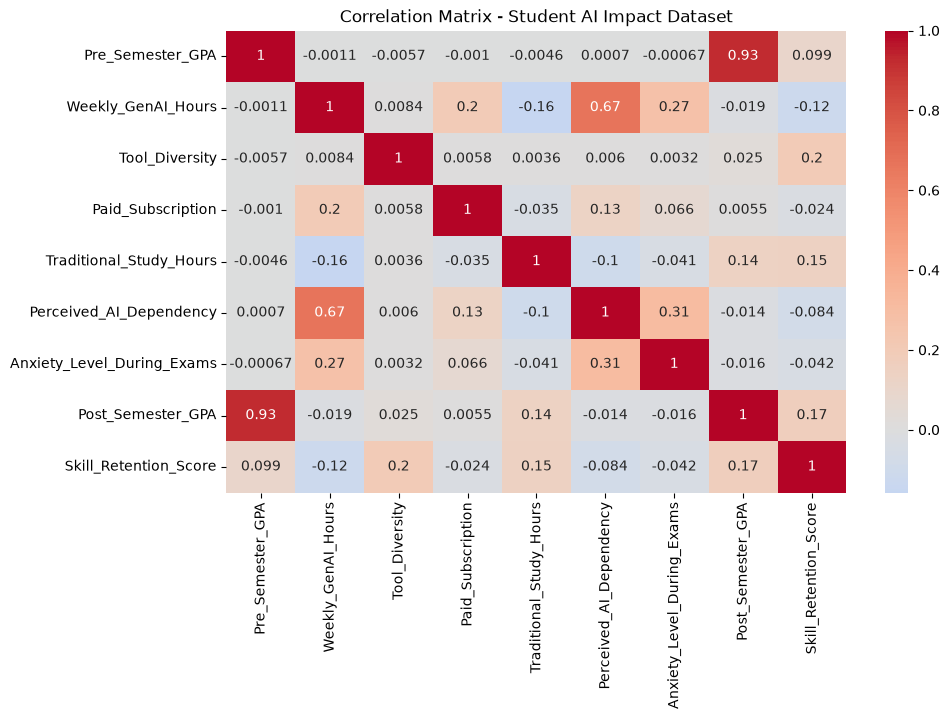

In [42]:
plt.figure(figsize=(10, 6))
data_corr = data_std.drop(columns=["Student_ID"])

corr_matrix = data_corr.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix - Student AI Impact Dataset")
plt.show()

La heatmap combinée à .corr() calcule et visualise la corrélation entre toutes les variables numériques simultanément. 
Les valeurs vont de -1 à +1 — rouge pour corrélation positive, bleu pour négative, blanc pour nulle. 
Les insights clés : Pre_Semester_GPA et Post_Semester_GPA à 0.93 confirment que le niveau académique initial est le meilleur prédicteur de réussite. 
Weekly_GenAI_Hours et Perceived_AI_Dependency à 0.67 montrent que plus on utilise l'IA plus on s'en sent dépendant. 
Perceived_AI_Dependency et Anxiety_Level_During_Exams à 0.31 indiquent que c'est la dépendance et non les heures d'utilisation qui génère l'anxiété.

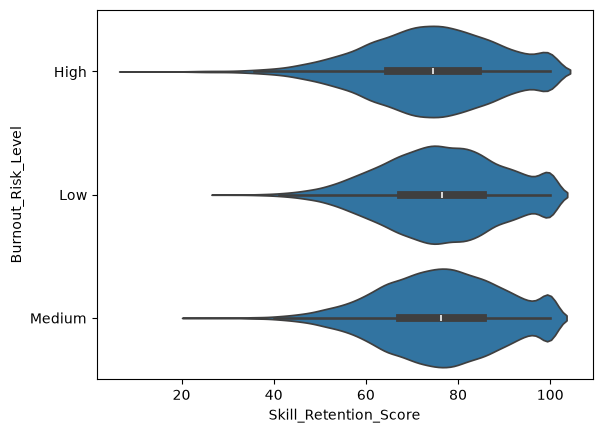

In [47]:
sns.violinplot(data=data_std, x="Skill_Retention_Score", y="Burnout_Risk_Level")
plt.show()

Le violinplot est une combinaison entre le boxplot et le KDE plot — 
il affiche simultanément la distribution des données via la forme extérieure et les quartiles via le boxplot intégré au centre. 
Plus la forme est large à un endroit, plus il y a d'étudiants concentrés à cette valeur. 
Sur Skill_Retention_Score par Burnout_Risk_Level, les trois violons Low, Medium et High ont des formes quasi identiques confirmant que le niveau de burnout n'impacte pas significativement la rétention des compétences. Seul le groupe High burnout s'étire légèrement vers les valeurs basses — cohérent avec ce qu'on avait observé sur le KDE plot.

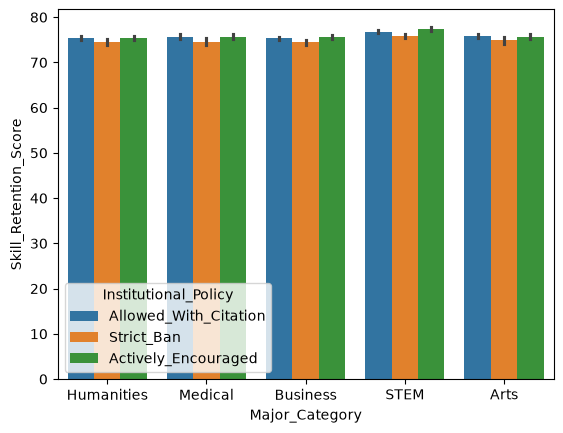

In [52]:
sns.barplot(data=data_std, y="Skill_Retention_Score", x="Major_Category", hue="Institutional_Policy")
plt.show()

Le barplot compare les moyennes d'une variable numérique entre différentes catégories. Sur Skill_Retention_Score par Major_Category, les moyennes sont quasi identiques entre filières — toutes autour de 75-76 — indiquant que la filière n'influence pas la rétention. En ajoutant hue="Institutional_Policy", une différence apparaît — les institutions appliquant la politique Allowed_With_Citation produisent les meilleurs scores de rétention. Conclusion : ni l'interdiction totale ni l'encouragement sans limite de l'IA n'est optimal. C'est l'encadrement avec citation qui favorise le mieux l'apprentissage actif et la rétention des compétences.

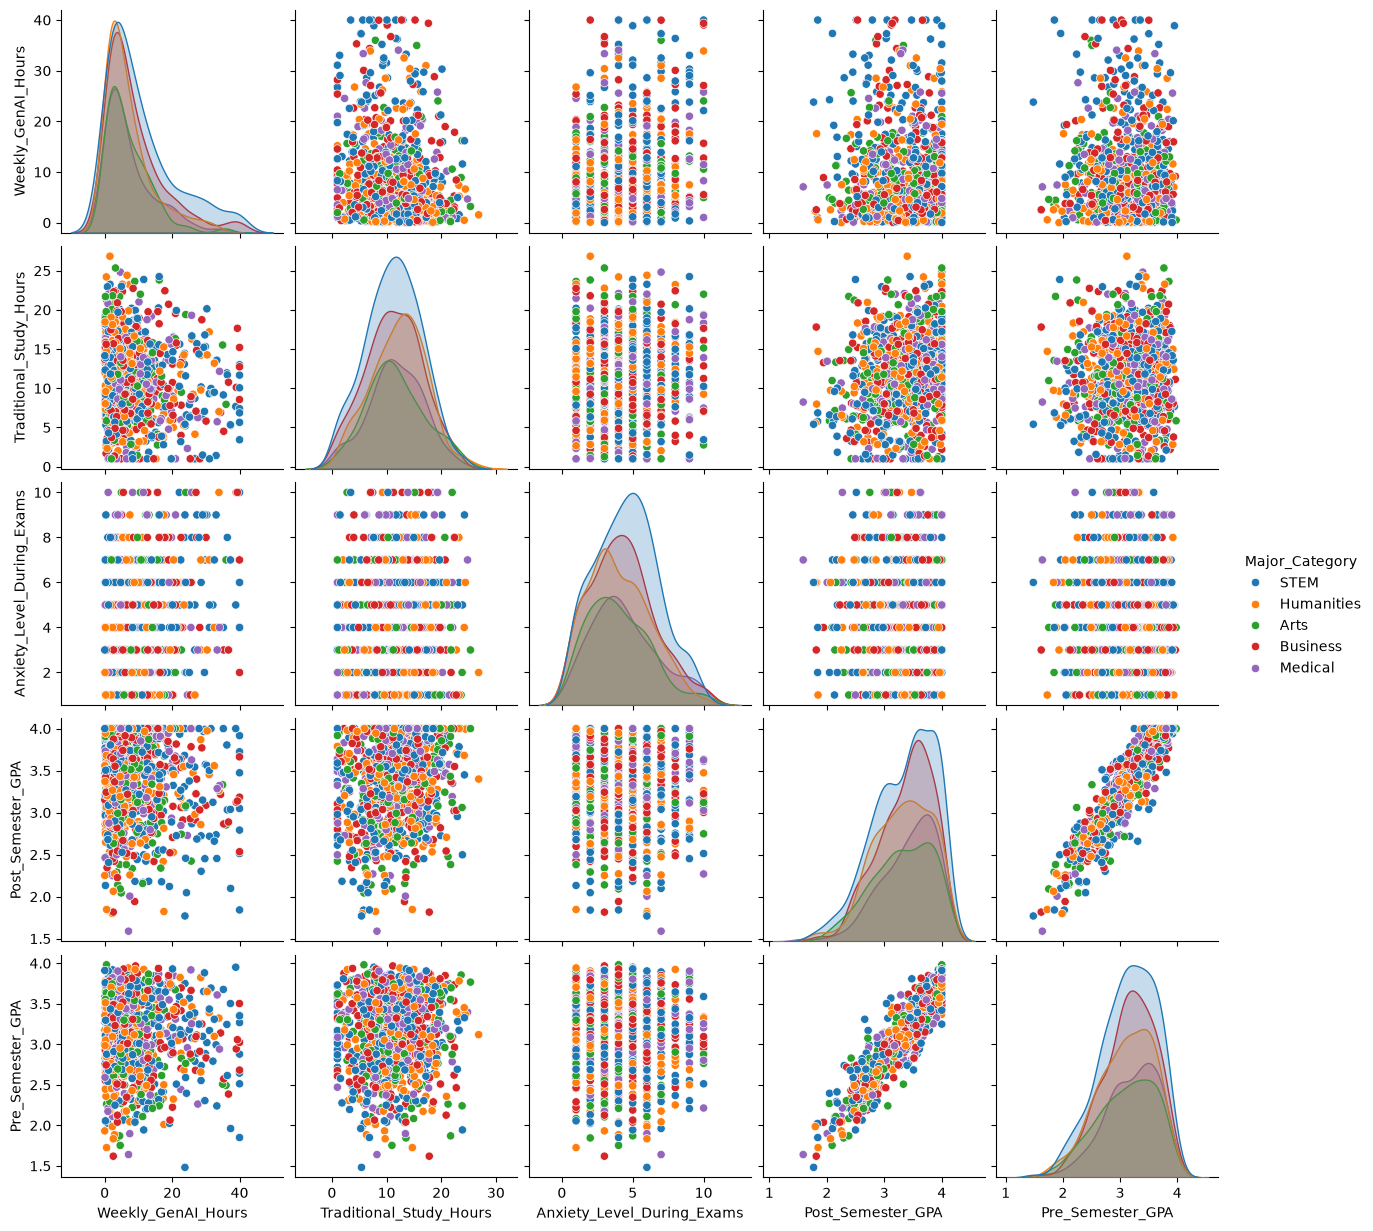

In [72]:
data_sample = data_std.sample(1000)

sns.pairplot(
    data=data_sample[[
        "Major_Category",
        "Weekly_GenAI_Hours",
        "Traditional_Study_Hours",
        "Anxiety_Level_During_Exams",
        "Post_Semester_GPA",
        "Pre_Semester_GPA"
        
    ]],
    hue="Major_Category"
)

plt.show()

Le pairplot est une grille de graphiques croisant toutes les variables sélectionnées deux à deux. 
La diagonale affiche la distribution de chaque variable — Weekly_GenAI_Hours est asymétrique à droite (5% d'outliers hauts), Traditional_Study_Hours et Anxiety_Level_During_Exams sont symétriques, Skill_Retention_Score est asymétrique à gauche (216 outliers bas). 
Hors diagonale, chaque case est un scatter plot entre deux variables. 
Les corrélations fortes sont visibles à l'œil — Pre_Semester_GPA vs Post_Semester_GPA à 0.93 montre clairement une tendance bas gauche vers haut droite. 
Les corrélations faibles comme Weekly_GenAI_Hours vs Traditional_Study_Hours à -0.16 sont quasi invisibles visuellement — pour celles-là on se fie aux chiffres de la heatmap. 
Règle clé : le pairplot détecte visuellement les corrélations fortes, la heatmap mesure précisément toutes les corrélations.